<a href="https://colab.research.google.com/github/RosarioH10062002/M2_master_thesis/blob/main/Data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ROOT_PATH = "/content/drive/My Drive/M2_Project_Master/Documents/Participants data/"

In [6]:
N_participants = 2
participants = [f"ID{x+1}" for x in range(N_participants)]

#LOAD DATA

In [83]:
root_id1 = ROOT_PATH + "ID1/BASELINE_ID1_20260309_101050.csv"
df_id1 = pd.read_csv(root_id1, sep = ";")
root_id2 = ROOT_PATH + "ID2/BASELINE_ID2_20260309_112213.csv"
df_id2 = pd.read_csv(root_id2, sep = ",")

In [100]:
df_id2.head(5)

,block_index,trial,trial_onset(s),stimulus_type,stimulus_code,resp_key,rt(s),fc(hz),fb(hz),correct
0,NaN,0,28.679098,No_go,0,NaN,NaN,NaN,NaN,Incorrect
1,NaN,1,30.657806,No_go,0,space,0.893748,NaN,NaN,Correct
2,NaN,2,31.635225,No_go,0,NaN,NaN,NaN,NaN,Incorrect
3,NaN,3,33.622636,No_go,0,space,0.443345,NaN,NaN,Correct
4,NaN,4,34.597662,No_go,0,NaN,NaN,NaN,NaN,Incorrect


#FIRST SESSION PLOTS



In [188]:
def clean_all_data(df):
  df = df.drop(["fc(hz)", "fb(hz)"], axis = 1)
  df["rt(s)"] = df["rt(s)"].fillna(0)
  df["trial"] = range(df.shape[0])
  return df

def plot_first_session(df, id):
  x_values = df["trial"]
  y_values = df["rt(s)"]

  plt.figure(figsize=(20, 6))
  plt.plot(x_values, y_values)
  plt.xlabel("Trial Number")
  plt.ylabel("Reaction Time (s)")
  plt.title(f"Reaction Time per Trial - ID{id}")
  plt.grid(True)

  plt.axvline(x=44, color='g', linestyle='--', label='Trial Phase')
  plt.axvline(x = 134, color='r', linestyle='--', label='Block 1 - Main Phase')
  plt.axvline(x = 224, color='r', linestyle='--', label='Block 2 - Main Phase')
  plt.axvline(x = 314, color='r', linestyle='--', label='Block 3 - Main Phase')
  plt.axvline(x = 404, color='r', linestyle='--', label='Block 4 - Main Phase')
  plt.axvline(x = 494, color='r', linestyle='--', label='Block 5 - Main Phase')
  plt.axvline(x = 584, color='r', linestyle='--', label='Block 6 - Main Phase')
  plt.legend()

  plt.show()

def compute_accuracy(df, trial):
  df_go_trials = df[df["stimulus_type"] == "Go"]
  n_total_go = df_go_trials.shape[0]
  #print(n_total_go)
  n_correct_go = df_go_trials[df_go_trials["correct"] == "Correct"].shape[0]
  accuracy_go = n_correct_go / n_total_go if n_total_go > 0 else 0

  df_no_go_trials = df[df["stimulus_type"] == "No_go"]
  n_total_no_go = df_no_go_trials.shape[0]
  #print(n_total_no_go)
  n_correct_no_go = df_no_go_trials[df_no_go_trials["correct"] == "Correct"].shape[0]
  accuracy_no_go = n_correct_no_go / n_total_no_go if n_total_no_go > 0 else 0

  if trial:
    label = "Trial"
  else:
    label = "Main Task"

  #print(f"Accuracy Go: {accuracy_go} \nAccuracy No Go: {accuracy_no_go}  \nPhase: {label}")
  return accuracy_go, accuracy_no_go

def compute_both_accuracy(df):
  [accuracy_go, accuracy_no_go] = compute_accuracy(df = df[0:45], trial = True) # trial
  all_accuracy_data = []
  all_accuracy_data.append({"Phase": "Trial", "Accuracy Go": accuracy_go, "Accuracy No Go": accuracy_no_go})

  for block in range(6):
    start = 45 + block*90
    end = start + 90
    #print(f"start: {start}, end {end}")
    [accuracy_go, accuracy_no_go] = compute_accuracy(df = df[start:end], trial = False)
    all_accuracy_data.append({"Phase": f"Block {block+1}", "Accuracy Go": accuracy_go, "Accuracy No Go": accuracy_no_go})
  return all_accuracy_data

def plot_accuracy(data, id):
  labels = [data[x].get("Phase") for x in range(7)]
  list_accuracy_go = [data[x].get("Accuracy Go") for x in range(7)]
  #print(list_accuracy_go)
  list_accuracy_no_go = [data[x].get("Accuracy No Go") for x in range(7)]
  plt.figure(figsize=(20, 6))
  plt.plot(labels, list_accuracy_go)
  plt.xlabel("Phase")
  plt.ylabel("Accuracy (%)")
  plt.title(f"Accuracy Go per Trial - ID{id}")
  plt.grid(True)
  plt.show()

  plt.figure(figsize=(20, 6))
  plt.plot(labels, list_accuracy_no_go)
  plt.xlabel("Phase")
  plt.ylabel("Accuracy (%)")
  plt.title(f"Accuracy No Go per Trial - ID{id}")
  plt.grid(True)
  plt.show()

In [145]:
labels = ["Trial"] + [f"Block {x+1}" for x in range(6)]
labels

['Trial', 'Block 1', 'Block 2', 'Block 3', 'Block 4', 'Block 5', 'Block 6']

#ID1

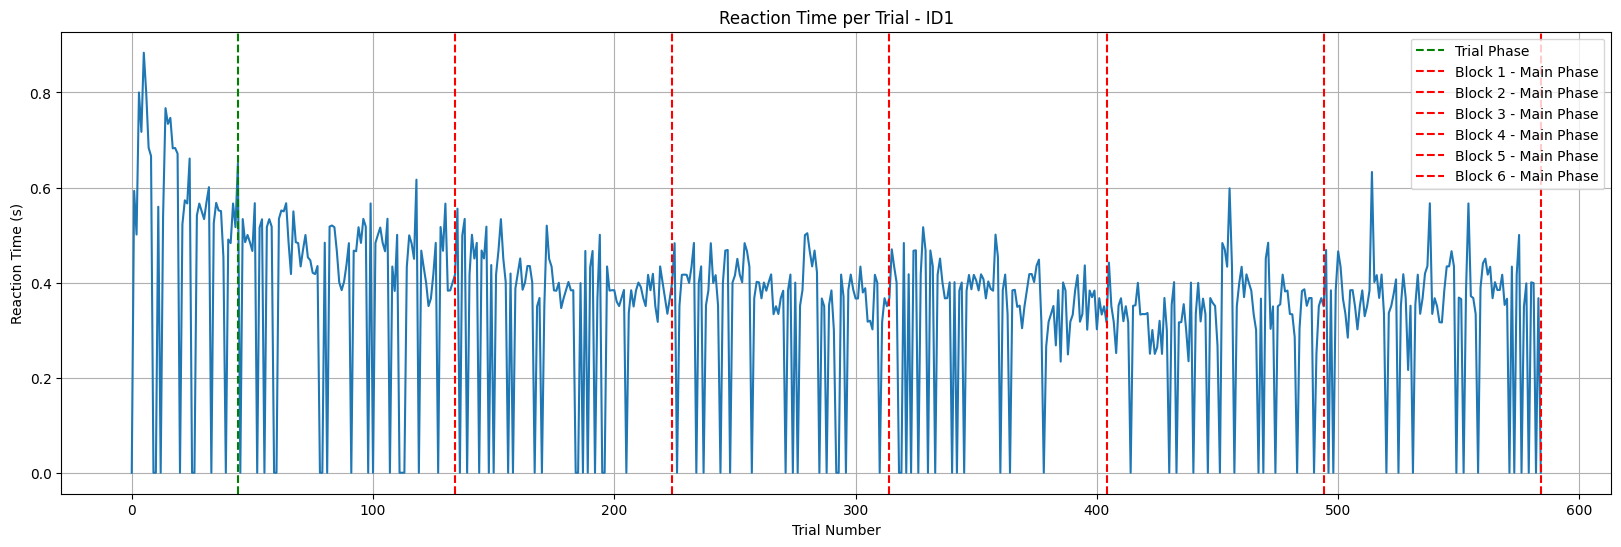

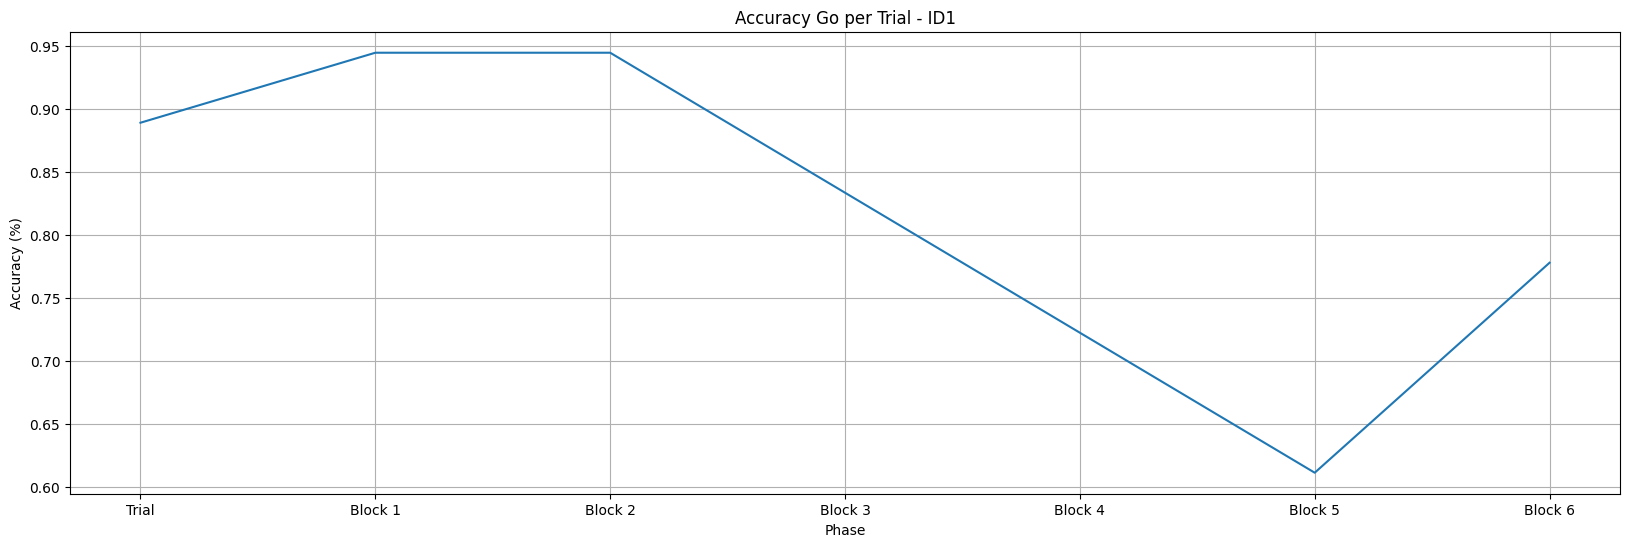

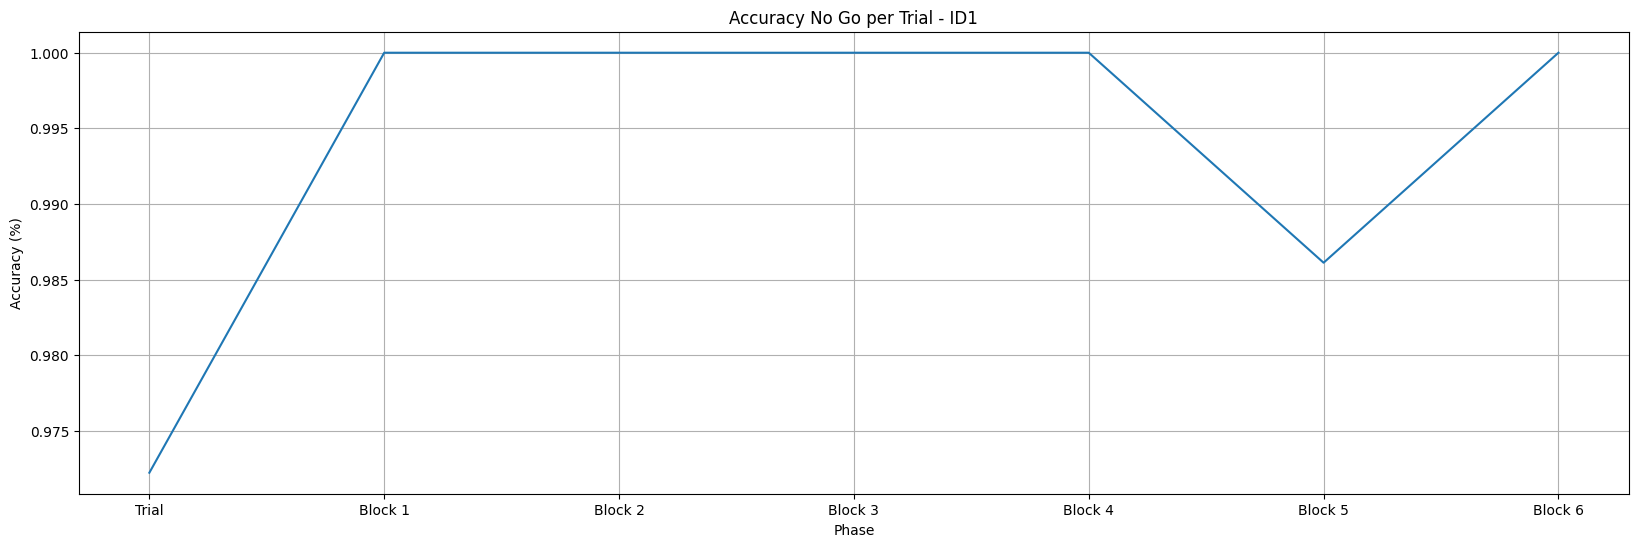

In [189]:
df = clean_all_data(df_id1)
plot_first_session(df, id = 1)
all_accuracy_data = compute_both_accuracy(df)
plot_accuracy(data = all_accuracy_data, id = 1)

#ID2

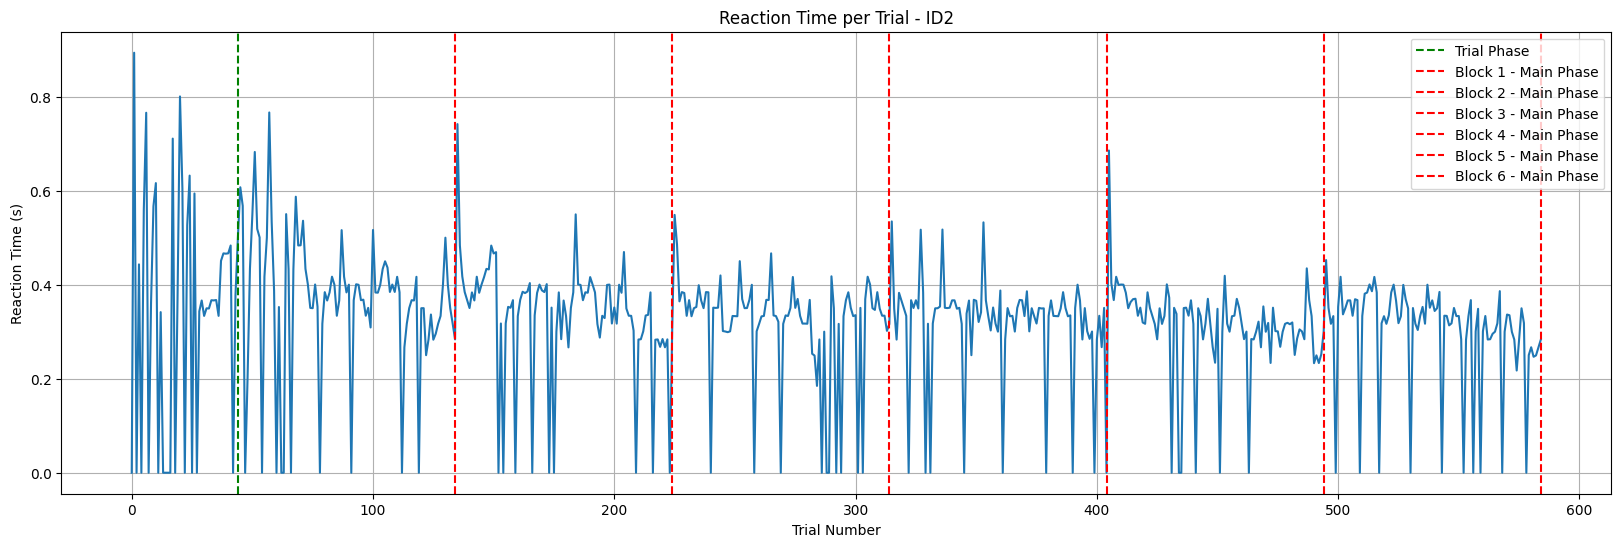

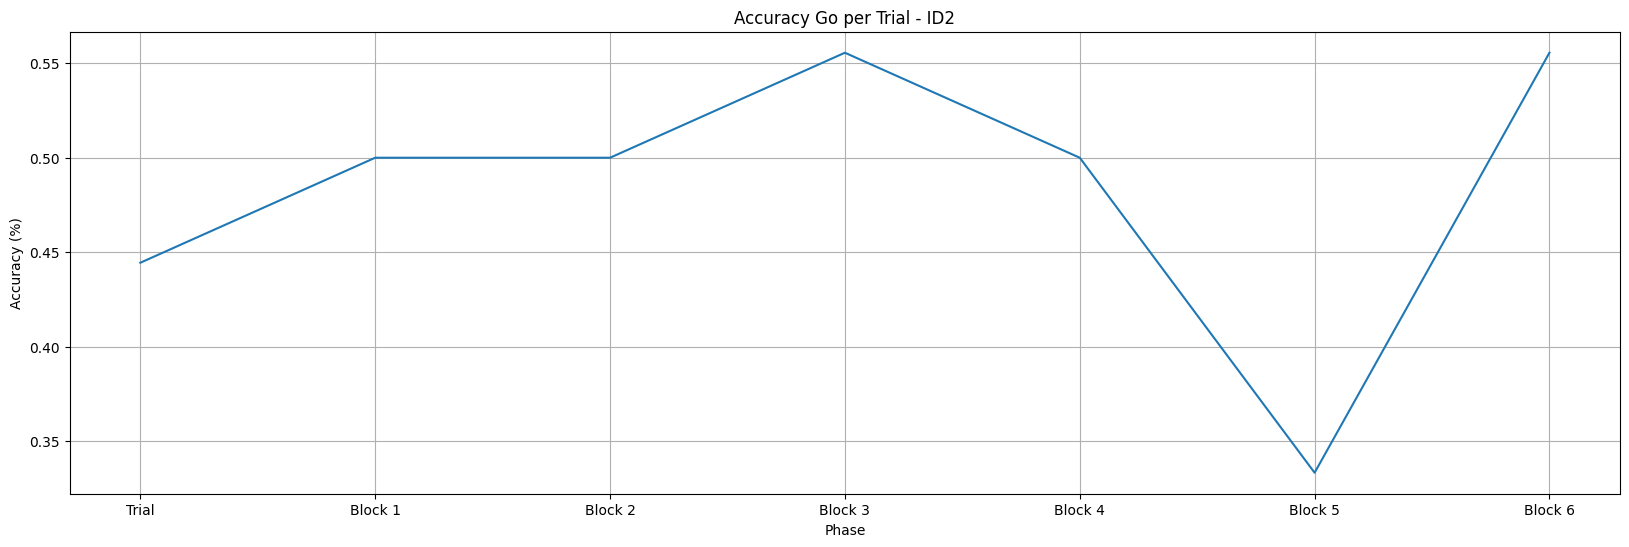

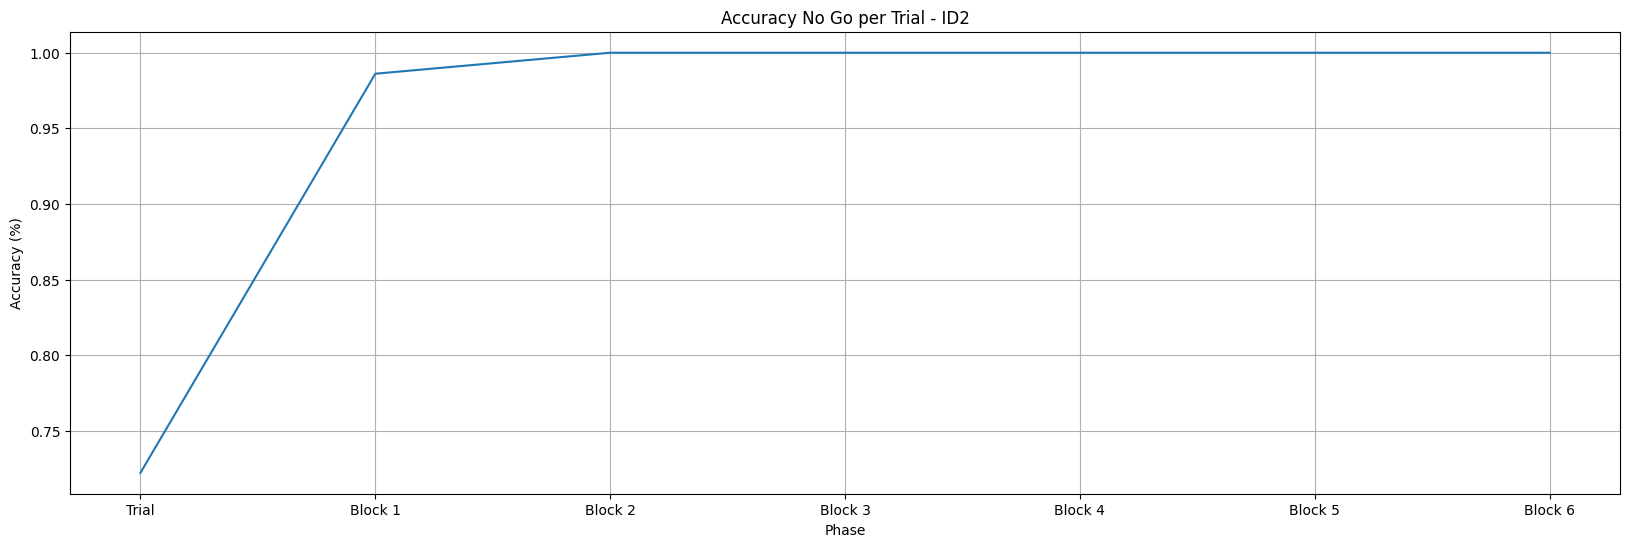

In [192]:
df = clean_all_data(df_id2)
plot_first_session(df, id = 2)
all_accuracy_data = compute_both_accuracy(df)
plot_accuracy(data = all_accuracy_data, id = 2)